# MLP on MNIST — Practice Notebook

Train a multilayer perceptron with PyTorch to classify MNIST digits: load the dataset, train with the shared `Trainer` loop, and inspect accuracy and predictions on the validation set.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torcheval.metrics.functional import multiclass_accuracy
from torchvision import datasets, transforms

from dl_roadmap.engine import ClassPredictor, Trainer, TrainerConfig
from dl_roadmap.models import MLP_MNIST
from dl_roadmap.utils import LoggerConfig, seed_everything, setup_logger
from dl_roadmap.visualization import plot_confusion_matrix, plot_training_history

In [3]:
%matplotlib inline

pd.set_option("display.width", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

seed_everything()
setup_logger(LoggerConfig(disable_logging=True))

## Dataset

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="../data/raw",
    train=True,
    download=True,
    transform=transform,
)
val_dataset = datasets.MNIST(
    root="../data/raw",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

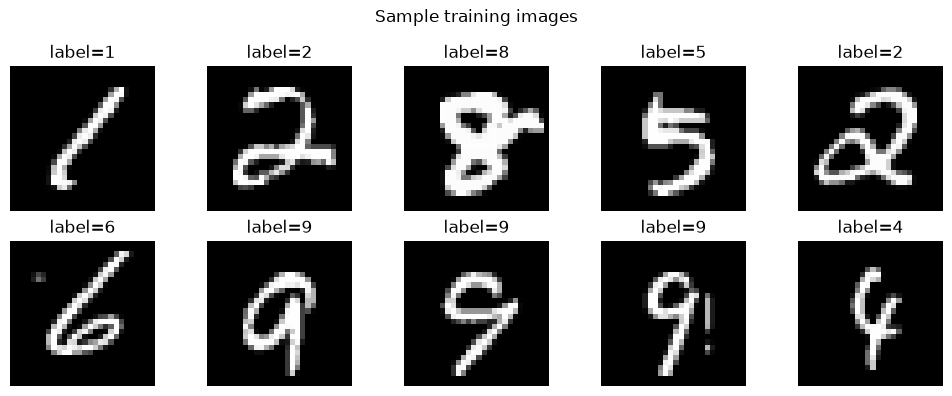

In [5]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for image, label, ax in zip(images, labels, axes.flatten()):
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(f"label={label.item()}")
    ax.axis("off")

plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

## Training

In [6]:
model = MLP_MNIST()

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

trainer_config = TrainerConfig(epochs=10)
trainer = Trainer(model, opt, loss_fn, config=trainer_config)
trainer.fit(train_loader, val_loader)

Epoch 10/10: 100%[====================] 9380/9380 :: eta=00:00, train_loss=0.01542, val_loss=0.07221 


## Results

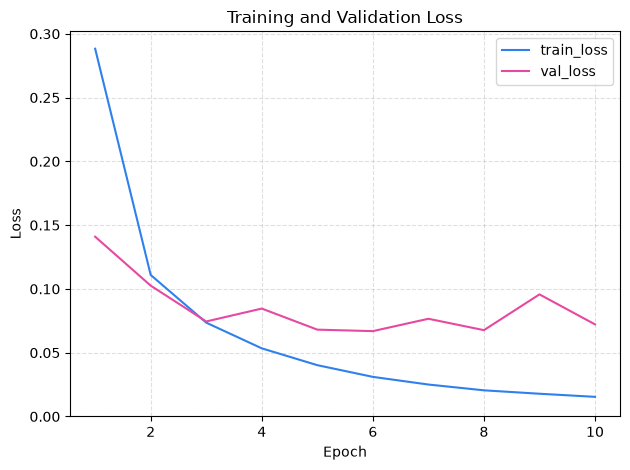

In [7]:
plot_training_history(**trainer.history)

In [8]:
X_val = torch.cat([xb for xb, *_ in val_loader])
y_val = torch.cat([yb for *_, yb in val_loader])

predictor = ClassPredictor(model)
y_pred = predictor.predict(X_val)

In [9]:
accuracy = multiclass_accuracy(y_pred, y_val)

print(f"Model accuracy: {accuracy}")

Model accuracy: 0.9810000061988831


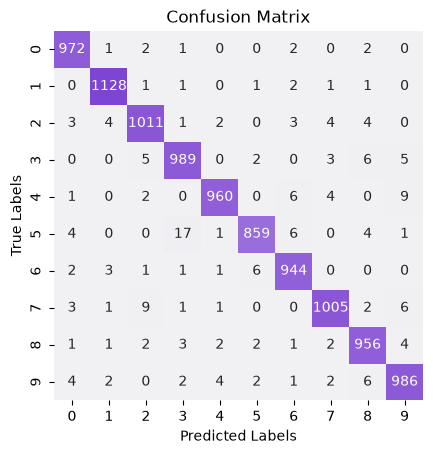

In [10]:
plot_confusion_matrix(y_pred, y_val)